# Task 4 — Pre-Processing Protocol Demo
**PlaceMux AI/ML Phase 1** | Leak-free preprocessing pipeline reusable at train and inference time

In [1]:
import sys, os; sys.path.insert(0, '..')
import numpy as np, pandas as pd, yaml, joblib
import matplotlib.pyplot as plt
from src.data.loader import load_data, split_data
from src.features.preprocessing import (
    build_preprocessor, fit_preprocessor, transform_split,
    save_preprocessor, load_preprocessor, verify_no_leakage)
from src.models.model import create_model
from src.evaluation.evaluate import evaluate
import random; random.seed(42); np.random.seed(42)
with open('../config/config.yaml') as f: cfg = yaml.safe_load(f)
print('✅ Setup complete')

✅ Setup complete


## 1 — Load Raw Data (with missing values)

In [2]:
X, y = load_data('../data/credit_fraud_dataset.csv', target_col='is_fraud')
print('Missing values per column:')
print(X.isnull().sum()[X.isnull().sum()>0])
X.head()

  [Loader] 1500 rows | 13 features | missing cells: 195 | target balance: {0: 1065, 1: 435}
Missing values per column:
age                      60
income                   45
transaction_amount       30
merchant_category        25
distance_from_home_km    35
dtype: int64


,age,income,credit_limit,transaction_amount,num_transactions_30d,account_age_months,num_prev_disputes,merchant_category,country_match,time_of_day_hour,is_weekend,card_present,distance_from_home_km
0,59.0,121894.0,60831.094518,2074.0,77,95,4,travel,1,1,0,0,9.232622
1,72.0,149302.0,26344.761228,2384.0,51,13,1,travel,1,16,0,0,70.805067
2,49.0,39289.0,11152.588421,327.0,50,28,4,electronics,1,19,0,1,2.596825
3,35.0,140359.0,38232.887796,1512.0,19,84,0,travel,1,3,1,1,40.314109
4,63.0,32927.0,7303.110250,2052.0,1,225,3,travel,1,12,0,1,17.472635


## 2 — Split FIRST (before any preprocessing)

In [3]:
X_tr, X_val, X_test, y_tr, y_val, y_test = split_data(X, y)
print(f'Nulls in X_train: {X_tr.isnull().sum().sum()}  |  X_test: {X_test.isnull().sum().sum()}')
print('KEY RULE: Splitting happens BEFORE preprocessing — test data never influences fitting')

  [Loader] Train:1050 | Val:225 | Test:225
Nulls in X_train: 144  |  X_test: 25
KEY RULE: Splitting happens BEFORE preprocessing — test data never influences fitting


## 3 — Build & Fit Preprocessor on X_train ONLY

In [4]:
preprocessor = build_preprocessor(X_tr)
preprocessor, X_tr_proc = fit_preprocessor(preprocessor, X_tr)
X_val_proc  = transform_split(preprocessor, X_val,  'X_val')
X_test_proc = transform_split(preprocessor, X_test, 'X_test')
print(f'Train: {X_tr.shape} → {X_tr_proc.shape} (OHE expanded categoricals)')

  [Preprocessor] Numeric (12): ['age', 'income', 'credit_limit', 'transaction_amount', 'num_transactions_30d', 'account_age_months', 'num_prev_disputes', 'country_match', 'time_of_day_hour', 'is_weekend', 'card_present', 'distance_from_home_km']
  [Preprocessor] Categorical (1): ['merchant_category']
  [Preprocessor] Transforms → Median Impute + StandardScale | MostFreq Impute + OneHotEncode
  [Preprocessor] fit_transform on X_train only ✅ (no test data seen)
  [Preprocessor] X_train shape after transform: (1050, 17)
  [Preprocessor] transform(X_val) — shape: (225, 17)  (fitted params reused, no leakage)
  [Preprocessor] transform(X_test) — shape: (225, 17)  (fitted params reused, no leakage)
Train: (1050, 13) → (1050, 17) (OHE expanded categoricals)


## 4 — Leakage Verification

In [5]:
verify_no_leakage(preprocessor)
print('\n❌ WRONG (what NOT to do):')
print('  preprocessor.fit_transform(X_test)  # would use test stats!')
print('\n✅ CORRECT (what we do):')
print('  preprocessor.fit_transform(X_train)  # fit only on train')
print('  preprocessor.transform(X_test)        # apply same params to test')


  [LeakageCheck] Numeric imputer medians (from X_train only):
    age                           : median=48.0000  scale_mean=47.6248
    income                        : median=85974.5000  scale_mean=85606.6848
    credit_limit                  : median=21738.7503  scale_mean=25425.9415
    transaction_amount            : median=2501.0000  scale_mean=2510.1076
    num_transactions_30d          : median=40.0000  scale_mean=39.1257
    account_age_months            : median=119.0000  scale_mean=117.6895
    num_prev_disputes             : median=2.0000  scale_mean=1.9829
    country_match                 : median=1.0000  scale_mean=0.9190
    time_of_day_hour              : median=12.0000  scale_mean=11.4924
    is_weekend                    : median=0.0000  scale_mean=0.3086
    card_present                  : median=1.0000  scale_mean=0.7781
    distance_from_home_km         : median=34.4071  scale_mean=51.0310

  [LeakageCheck] Categorical imputer modes (from X_train only):
    mercha

## 5 — Before vs After Transformation

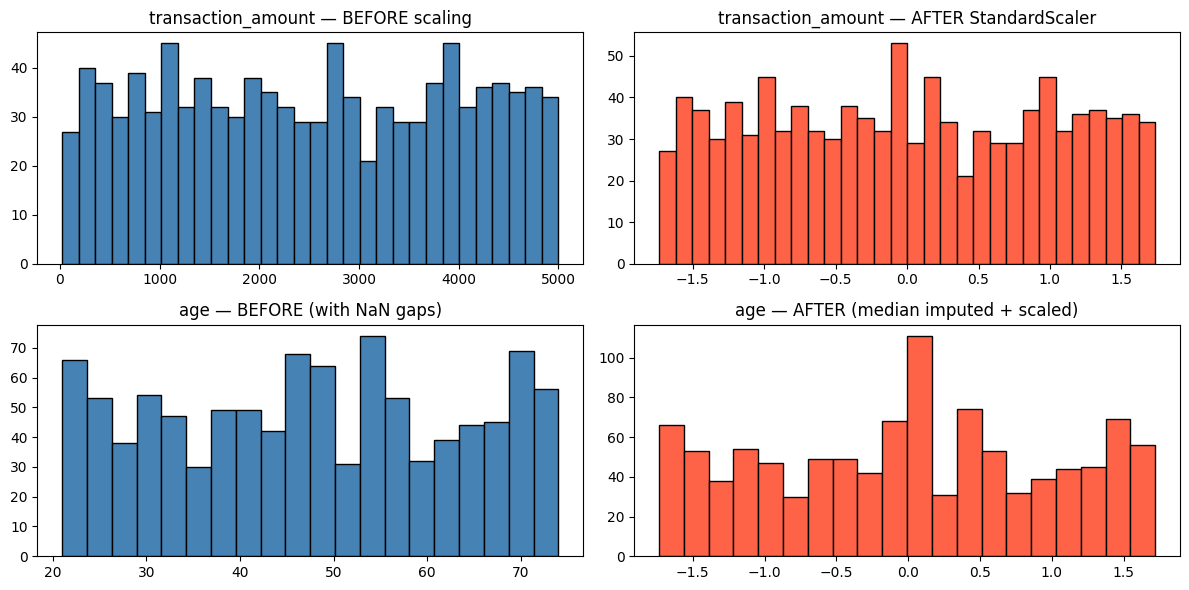

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
col_before = X_tr['transaction_amount'].dropna()
idx = list(X_tr.columns).index('transaction_amount')
col_after = X_tr_proc[:, idx]
axes[0,0].hist(col_before, bins=30, color='steelblue', edgecolor='black')
axes[0,0].set_title('transaction_amount — BEFORE scaling')
axes[0,1].hist(col_after,  bins=30, color='tomato',    edgecolor='black')
axes[0,1].set_title('transaction_amount — AFTER StandardScaler')
age_before = X_tr['age'].dropna()
idx2 = list(X_tr.columns).index('age')
age_after = X_tr_proc[:, idx2]
axes[1,0].hist(age_before, bins=20, color='steelblue', edgecolor='black')
axes[1,0].set_title('age — BEFORE (with NaN gaps)')
axes[1,1].hist(age_after,  bins=20, color='tomato',    edgecolor='black')
axes[1,1].set_title('age — AFTER (median imputed + scaled)')
plt.tight_layout()
plt.savefig('../artifacts/transform_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 6 — Train Model & Evaluate

In [7]:
model = create_model('logistic', {}, 42)
model.fit(X_tr_proc, y_tr)
m = evaluate(model, X_val_proc, y_val, 'val')
print(f'Val F1: {m["f1_macro"]}')

  [Model] Created 'logistic' → LogisticRegression(random_state=42)

  [VAL] acc=0.7867 prec=0.7477 rec=0.6993 f1=0.7147
              precision    recall  f1-score   support

   Not Fraud       0.81      0.91      0.86       160
       Fraud       0.68      0.49      0.57        65

    accuracy                           0.79       225
   macro avg       0.75      0.70      0.71       225
weighted avg       0.78      0.79      0.78       225

Val F1: 0.7147


## 7 — Save & Reload for Inference

In [8]:
save_preprocessor(preprocessor, '../artifacts/preprocessor.pkl')
loaded_pp = load_preprocessor('../artifacts/preprocessor.pkl')

# Simulate new incoming row with missing value & unseen category
new_row = pd.DataFrame([{
    'age': None, 'income': 72000, 'credit_limit': 18000,
    'transaction_amount': 3200, 'num_transactions_30d': 22,
    'account_age_months': 60, 'num_prev_disputes': 1,
    'merchant_category': 'supermarket',  # unseen category!
    'country_match': 0, 'time_of_day_hour': 3,
    'is_weekend': 1, 'card_present': 0, 'distance_from_home_km': None
}])
result = loaded_pp.transform(new_row)
print('New row (raw):', new_row[['age','merchant_category','distance_from_home_km']].to_dict('records')[0])
print(f'Transformed shape: {result.shape}')
print('✅ Inference works — missing values imputed, unseen category handled gracefully')

  [Preprocessor] Saved → ../artifacts/preprocessor.pkl
  [Preprocessor] Loaded ← ../artifacts/preprocessor.pkl  (ready for inference)
New row (raw): {'age': None, 'merchant_category': 'supermarket', 'distance_from_home_km': None}
Transformed shape: (1, 17)
✅ Inference works — missing values imputed, unseen category handled gracefully


## ✅ Task 4 Checklist

| Item | Status |
|---|---|
| Split before preprocessing | ✅ |
| Numeric: MedianImputer + StandardScaler | ✅ |
| Categorical: MostFreqImputer + OneHotEncoder | ✅ |
| ColumnTransformer combines both | ✅ |
| fit only on X_train | ✅ |
| transform() on val/test | ✅ |
| Leakage verified & documented | ✅ |
| preprocessor.pkl saved | ✅ |
| Inference from saved file works | ✅ |
| Unseen category handled | ✅ |